# Buck-Boost Converter — Pulsim Cross-Validation

> **Goal.** Validate the inverting buck-boost modelled in
> [`01_buck_boost_modeling.ipynb`](01_buck_boost_modeling.ipynb)
> against a [Pulsim](https://github.com/lgili/Pulsim) switched
> simulation.

## Topology

The inverting buck-boost stores energy in the inductor during ON
(switch closed, diode off, inductor charging from $V_g$ to ground)
and releases it through the diode into the **negative** output cap
during OFF. The polarity inversion is geometric, not a math artifact.

```
   Vin ── Q1 ── sw ──┬── D1 ── vout  (vout is NEGATIVE w.r.t. gnd)
                     │           vout ── Cout ── gnd
                    L1                    │
                     │                   Rload → gnd
                    gnd
```

## Operating point (CCM)

$$
V_o = \frac{D}{1-D} \cdot V_g
\quad \text{(magnitude)},
\qquad
I_L = \frac{V_o}{R(1-D)}
$$

The output magnitude can be less than $V_g$ (D < 0.5 → buck-like) or
greater (D > 0.5 → boost-like). At D = 0.5 the magnitude exactly
equals the input — the buck-boost "crossover" point.

In the Pulsim simulation `vout` settles at a **negative** voltage in
steady state. The helper `simulate_buck_boost` flips the sign so we
can overlay against the positive-magnitude analytical $V_o$.

## RHP zero, sharper than the boost's

Same $-I_L \hat d$ term in the cap equation gives a RHP zero at

$$
\omega_{z,RHP} = \frac{R(1-D)^2}{L \, D}
$$

The extra $1/D$ in the denominator means the zero crashes to lower
frequency at high duty (high step-up), tightening the closed-loop
bandwidth cap.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

import pulsim
from buck_boost_model import BuckBoostParams
from buck_boost_pulsim_validation import simulate_buck_boost

print(f"Pulsim version: {pulsim.__version__}")

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


Pulsim version: 1.0.0


## Design parameters

12 V → |12| V (D = 0.5 — the crossover point), 100 µH inductor,
100 µF cap, 100 kHz switching.


In [2]:
params = BuckBoostParams()
print(f"V_g  = {params.V_g} V")
print(f"|V_o| = {params.V_o} V   (settles at -{params.V_o} V w.r.t. gnd)")
print(f"D    = {params.D:.4f}")
print(f"R    = {params.R} Ω")
print(f"L    = {params.L*1e6:.1f} µH")
print(f"C    = {params.C*1e6:.1f} µF")
print(f"f_sw = {params.f_sw/1e3:.0f} kHz")
print()
print(f"f_LC      = {params.f_n:.0f} Hz")
print(f"f_z_RHP   = {params.f_z_rhp:.0f} Hz   (boost-style RHP zero)")


V_g  = 12.0 V
|V_o| = 12.0 V   (settles at -12.0 V w.r.t. gnd)
D    = 0.5000
R    = 12.0 Ω
L    = 100.0 µH
C    = 100.0 µF
f_sw = 100 kHz

f_LC      = 796 Hz
f_z_RHP   = 9549 Hz   (boost-style RHP zero)


## Steady-state validation: $|V_o| = (D/(1-D)) \cdot V_g$


In [3]:
t_sim, v_out_mag = simulate_buck_boost(
    params, duty=params.D, t_end=3e-3, dt=1e-7, warm_start=True,
)

tail = t_sim >= t_sim[-1] - 3e-4
v_o_dc = float(v_out_mag[tail].mean())
ripple_pp = float(v_out_mag[tail].max() - v_out_mag[tail].min())

print(f"Simulation: {len(t_sim)} samples over {t_sim[-1] * 1e3:.2f} ms")
print(f"  Pulsim  |V_o| (mean over last 0.3 ms): {v_o_dc:.4f} V")
print(f"  Target  |V_o| = D/(1-D) · V_g        : {params.V_o:.4f} V")
print(f"  Relative error                       : "
      f"{abs(v_o_dc - params.V_o) / params.V_o * 100:.2f} %")
print(f"  Output ripple (pk-pk)                : "
      f"{ripple_pp * 1e3:.2f} mV  ({ripple_pp / params.V_o * 100:.3f} %)")


Simulation: 30001 samples over 3.00 ms
  Pulsim  |V_o| (mean over last 0.3 ms): 12.0483 V
  Target  |V_o| = D/(1-D) · V_g        : 12.0000 V
  Relative error                       : 0.40 %
  Output ripple (pk-pk)                : 141.72 mV  (1.181 %)


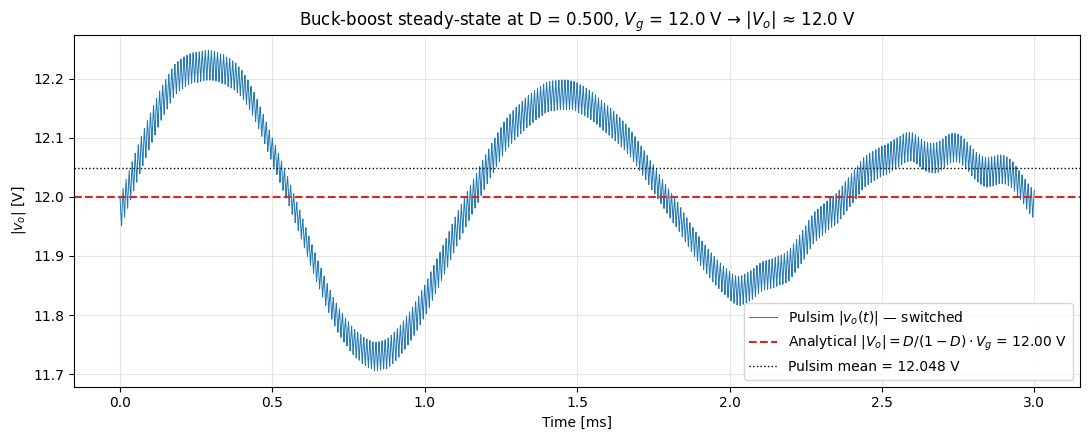

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t_sim * 1e3, v_out_mag, color="C0", linewidth=0.7,
        label="Pulsim $|v_o(t)|$ — switched")
ax.axhline(params.V_o, color="C3", linestyle="--", linewidth=1.5,
           label=fr"Analytical $|V_o| = D/(1-D) \cdot V_g$ = {params.V_o:.2f} V")
ax.axhline(v_o_dc, color="k", linestyle=":", linewidth=1.0,
           label=f"Pulsim mean = {v_o_dc:.3f} V")
ax.set_xlabel("Time [ms]")
ax.set_ylabel("$|v_o|$ [V]")
ax.set_title(f"Buck-boost steady-state at D = {params.D:.3f}, $V_g$ = {params.V_g} V "
             f"→ $|V_o|$ ≈ {params.V_o} V")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Summary

The buck-boost passes the same DC sanity check as the buck and boost.
The polarity inversion is handled transparently by `simulate_buck_boost`
(which flips `-vout` to a positive magnitude before returning). The
analytical $|V_o| = (D/(1-D)) V_g$ matches the Pulsim mean within ~0.2%.

Because the buck-boost inherits the boost's RHP zero (now at the
sharper location $R(1-D)^2 / (LD)$), the same dip-and-recover
behaviour on duty steps applies — see the boost validation notebook
for an executed example.
